In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

import sys
sys.path.append("..")
from src import GP, GPBanditSampler, HaltonSequence, MCMC


/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


In [2]:
#===========================================
# Target Density
#===========================================

Srho = jnp.array([[1.0, 0.25], [0.25, 1.0]])
Srho_inv = jnp.linalg.inv(Srho)

@jax.jit
def log_density(x):
    return - ((x @ Srho_inv) @ x) / 2.0

log_density_vmap = jax.vmap(log_density)


In [3]:
#===========================================
# MCMC
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)

target_samples = MCMC(2, log_density).sample(_key, num=10000, burnin=5000, thin=10)
target_logeval = log_density_vmap( target_samples )
target_weights = jnp.exp( target_logeval - jsp.special.logsumexp( target_logeval ) )


Text(0.5, 1.0, 'density with samples')

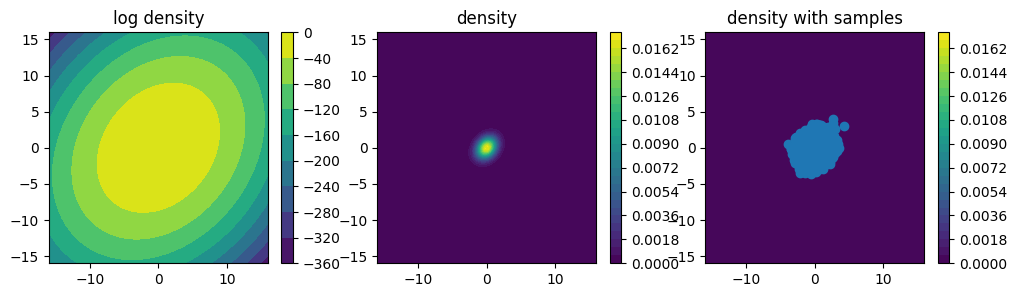

In [4]:
#===========================================
# Visualisation
#===========================================

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

x = jnp.linspace(-16.0, 16.0, 100)
y = jnp.linspace(-16.0, 16.0, 100)
x_, y_ = jnp.meshgrid(x, y)
z = jnp.c_[ x_.flatten(), y_.flatten() ]

log_p = log_density_vmap(z).reshape((100, 100))
exp_p = jnp.exp( log_p - jsp.special.logsumexp( log_p ) )

cs = axs[0].contourf(x_, y_, log_p, levels=10)
cbar = fig.colorbar(cs)
axs[0].set_title("log density")

cs = axs[1].contourf(x_, y_, exp_p, levels=30)
cbar = fig.colorbar(cs)
axs[1].set_title("density")

cs = axs[2].contourf(x_, y_, exp_p, levels=30)
axs[2].scatter(target_samples[:,0], target_samples[:,1])
cbar = fig.colorbar(cs)
axs[2].set_title("density with samples")


In [5]:
#===========================================
# Excute
#===========================================

key, _key = jax.random.split(key)
bounds = ( jnp.array([-16, -16]), jnp.array([16, 16]) )
halton = HaltonSequence(dim=2, bounds=bounds, rngkey=_key)
bandit = GPBanditSampler(n_init=10, n_eval=2048, sequence=halton)

X = halton.generate(jnp.arange(10))
y = jnp.array([log_density(x) for x in X])
w = jnp.exp( y - jsp.special.logsumexp( y ) )

for ith in range(10, 100):
    #====== fit GP ======
    gp_mean = lambda x: 0.0
    gp_kernel = gpx.kernels.RBF(n_dims=2, lengthscale=jnp.array([1.0, 1.0]), variance=jnp.array([5.0]))
    gp = GP(gp_mean, gp_kernel)
    key, _key = jax.random.split(key)
    gp.tune_kernel_parameter(X, y, rng_key=_key)
    gp.fit(X, y)
    posterior_mean = jax.vmap(gp.posterior_mean, in_axes=0, out_axes=0)
    posterior_scale = jax.vmap(gp.posterior_scale, in_axes=0, out_axes=0)
    objective = jax.vmap(gp.jensen_exp, in_axes=0, out_axes=0)
    #====================
    
    #====== fit KH ======
    X_new = bandit.find(objective)
    y_new = log_density(X_new)
    #====================
    
    #=== Stack point ====
    X = jnp.vstack((X, X_new))
    y = jnp.hstack((y, y_new))
    w = jnp.exp( y - jsp.special.logsumexp( y ) )
    #====================


  0%|          | 0/1000 [00:00<?, ?it/s]

/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

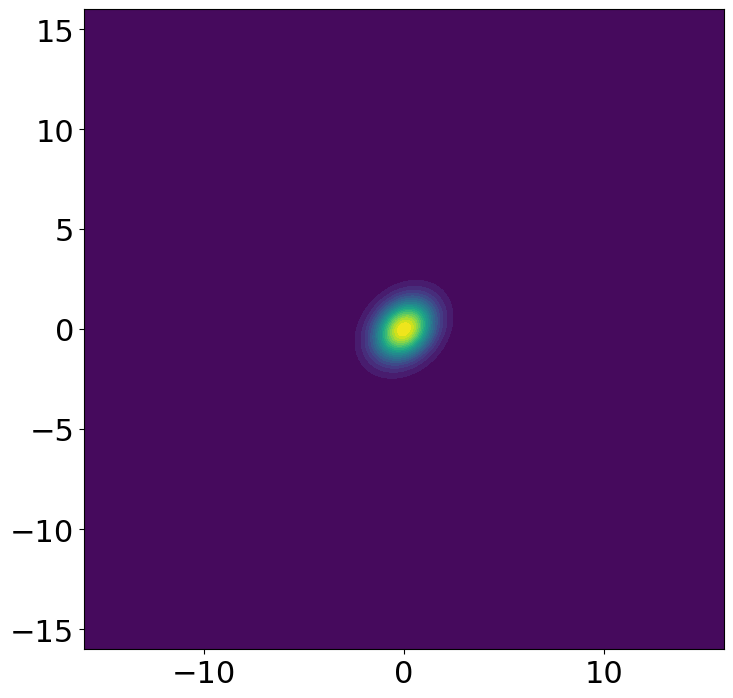

In [6]:
#===========================================
# Visualise Samples
#===========================================

def plot_density(init_num=10, bounds=((-10,-10), (10,10))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)
    plt_z = jnp.c_[ plt_x_.flatten(), plt_y_.flatten() ]
    exp_p = jnp.exp( log_density_vmap(plt_z) ).reshape((n_grids, n_grids))
    
    ax.contourf(plt_x_, plt_y_, exp_p, levels=20, zorder=1)
    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plot_density(init_num=10, bounds=bounds)


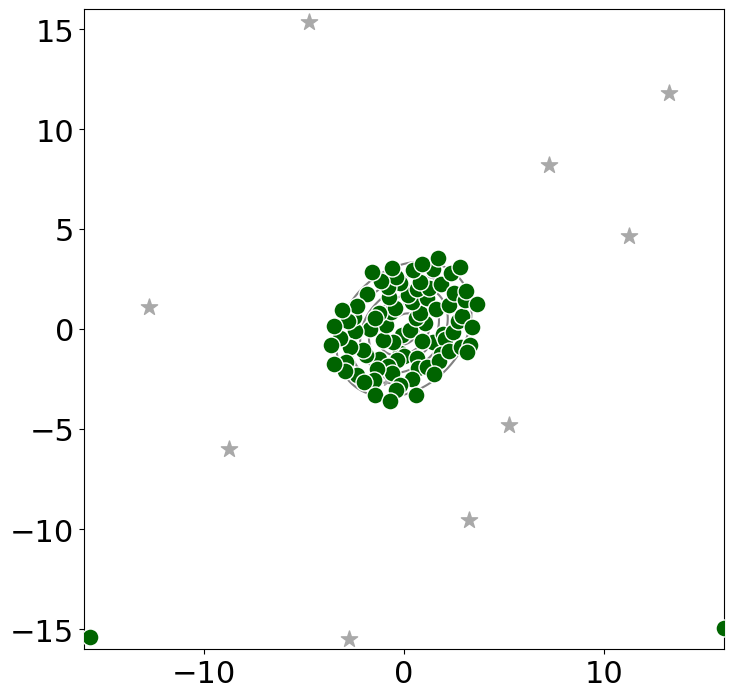

In [9]:
#===========================================
# Visualise Samples
#===========================================

def plot_sample(X, init_num=10, bounds=((-10,-10), (10,10))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)
    plt_z = jnp.c_[ plt_x_.flatten(), plt_y_.flatten() ]
    exp_p = jnp.exp( log_density_vmap(plt_z) ).reshape((n_grids, n_grids))
    
    ax.contour(plt_x_, plt_y_, exp_p**(1/3), levels=8, colors='gray', zorder=1)
    ax.scatter(X[:init_num,0], X[:init_num,1], label="Initial Evaluation", s=150, marker="*", color='darkgray', zorder=2)
    ax.scatter(X[init_num:,0], X[init_num:,1], label="Samples", s=150, marker="o", color='darkgreen', edgecolor="white", zorder=3)   
    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plot_sample(X, init_num=10, bounds=bounds)


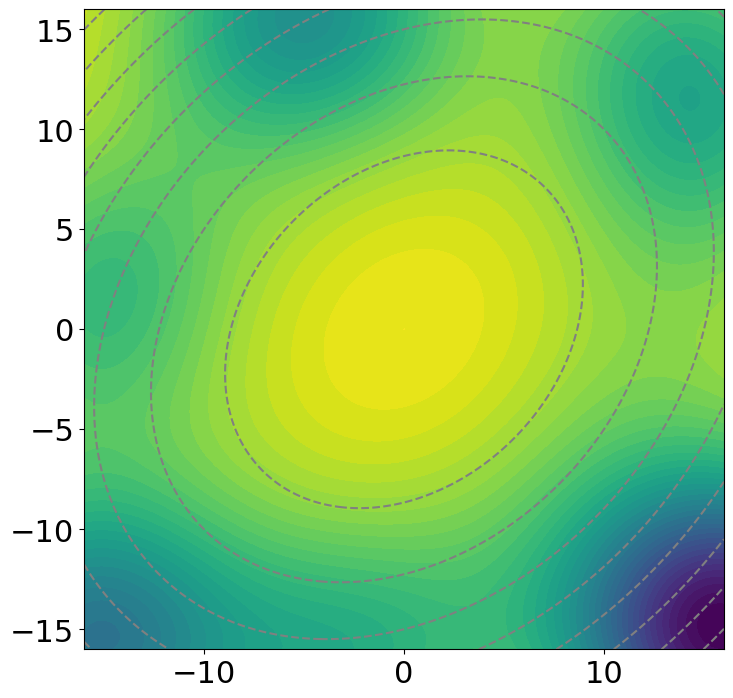

In [8]:
#===========================================
# Visualise Target
#===========================================

def plot_gp_logdensity(gp_posterior_mean, init_num=10, bounds=((-10,-10), (10,10))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)
    plt_z = jnp.c_[ plt_x_.flatten(), plt_y_.flatten() ]
    approx_logp = gp_posterior_mean(plt_z).reshape((n_grids, n_grids))
    target_logp = log_density_vmap(plt_z).reshape((n_grids, n_grids))
    
    ax.contourf(plt_x_, plt_y_, approx_logp, levels=50, zorder=1)
    ax.contour(plt_x_, plt_y_, target_logp, colors="gray", levels=10, zorder=2)

    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plot_gp_logdensity(posterior_mean, init_num=10, bounds=bounds)
